# GRiD STAC API Tutorial
In this tutorial we'll walk through the capabilities that the STAC API provides and how to connect to it using the `pystac-client`, a python library that can connect and interact with any STAC API.

1. Introduction
2. Getting Started
3. Connect to the API
4. Query Collections
5. Item Search
6. CQL2 Search
7. Downloading data


## Introduction
The SpatioTemporal Access Catalogs(STAC) specification, is a common language to describe geospatial information. STAC provides a framework for data providers to advertise data to their interested clients in a way that is easy to discover, consume, and index.

More in-depth information about STAC can be found [on their webpage](https://stacspec.org/en), where they have indepth descriptions and examples for Data Providers, Developers, and Data Users.

STAC is the method by which we describe the data, and the API is similarly a common way for people to interact with it. Having a common specification means we can interact with two different APIs and expect to be able to interact with them in the same way and achieve similar results.

The information in this document should not only be able to help you interact with GRiD's api, but also any other STAC API implementation you may find yourself interested in in the future.

## Getting Started

### Installing Dependencies
To run this tutorial, you'll need `Python` and the `pystac-client` library. The easiest way to do this will be with the `pip` Python package manager.


In [1]:
!pip install -q pystac-client cql2 ipyleaflet jupyter-leaflet

### Creating an Access Token
Before we begin with using `pystac-client`, we'll need to get an API Token from GRiD. To learn how to create an access token follow `API -> Quickstart Guide` and follow the instructions under the `Getting an Access Token` header.

Your access token should now be available under `API -> Manage Token`. Copy and paste the value under `Access Token` into the code box below this.

In [2]:
# @title API Setup

api_token = '' # @param {type:"string"}
grid_url = 'https://grid.nga.mil/testgrid/api/v5/stac' # @param {type:"string"}

if grid_url and api_token:
    print("We're all set to start using GRiD's STAC API!")
elif not api_token:
    print("Please provide a GRiD API token to proceed.")
    raise ValueError("Missing API Token.")
elif not grid_url:
    print("Please provide a GRiD API URL to proceed.")
    raise ValueError("Missing API URL.")


We're all set to start using GRiD's STAC API!


## Connect to the API
To start off, we'll need to connect to GRiD's STAC API using the token you brought. GRiD makes use of the [Authentication Extension](https://github.com/stac-extensions/authentication) to tell STAC clients that we're expected to use a `Bearer` auth flow on the front end, and behind the scenes GRiD will further authenticate and filter your results based on your personal access to resources.



In [3]:
import json
from pystac_client import Client
import logging

# uncomment if you want verbose curl logs
# logging.basicConfig()
# logger = logging.getLogger("pystac_client")
# logger.setLevel(logging.DEBUG)

headers = {'Authorization': f'Bearer {api_token}', 'Referrer-Policy': 'origin'}
client = Client.open(grid_url, headers=headers)
print(f'Now connected to {client.title}!')

Now connected to GRiD STAC Catalog!


### Conformance
Conformance is very important for STAC APIs. Users should be able to expect that if two STAC APIs have the same conformance, then the ways in which you can interact with them will be the same.

Much like base STAC, the API can also be extended. Each STAC API Extension will require different specs to conform. Some extensions are bundled with the [STAC API SPEC](https://github.com/radiantearth/stac-api-spec), and some are bundled in the [STAC API Extension Github org](https://stac-api-extensions.github.io/) so they can follow their own release/maturity cycle.

In the section below, we'll illustrate how to list what specs GRiD conforms to, and how to check if GRiD conforms to a specific specification.

In [4]:
conformance = json.dumps(client.get_conforms_to(), indent=2)
print('GRiD\'s STAC API conforms to these parameters.\n', conformance)

# we can check that GRiD conforms to a specific feature with the conforms_to method
print("Does GRiD conform to the Item Search feature?")
if client.conforms_to("ITEM_SEARCH"):
    print("Yes!")
else:
    print("No.")


GRiD's STAC API conforms to these parameters.
 [
  "http://www.opengis.net/spec/cql2/1.0/conf/advanced-comparison-operators",
  "http://www.opengis.net/spec/cql2/1.0/conf/basic-cql2",
  "http://www.opengis.net/spec/cql2/1.0/conf/cql2-json",
  "http://www.opengis.net/spec/cql2/1.0/conf/cql2-text",
  "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/core",
  "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/geojson",
  "http://www.opengis.net/spec/ogcapi-features-1/1.0/conf/oas30",
  "http://www.opengis.net/spec/ogcapi-features-3/1.0/conf/features-filter",
  "http://www.opengis.net/spec/ogcapi-features-3/1.0/conf/filter",
  "https://api.stacspec.org/v1.0.0-rc.1/item-search#free-text",
  "https://api.stacspec.org/v1.0.0-rc.2/item-search#filter",
  "https://api.stacspec.org/v1.0.0/collections",
  "https://api.stacspec.org/v1.0.0/core",
  "https://api.stacspec.org/v1.0.0/item-search",
  "https://api.stacspec.org/v1.0.0/item-search#fields",
  "https://api.stacspec.org/v1.0.0/item

## Query Collections
The Client object that we created earlier is connected to the landing page of the STAC API, and represents a [Catalog](https://github.com/radiantearth/stac-spec/blob/master/catalog-spec/catalog-spec.md). It can be interacted with as if it's a Catalog, including showing its children.

We'll start off by selecting the first one in the list as our example Collection.

In [5]:
cols = client.get_collections()
col_list = list(cols)
print(f"We found {len(col_list)} collections in the base Catalog.")

# We'll use the first one as an example
desired_col = col_list[0]

We found 26 collections in the base Catalog.


We can also print out some information about the collection that we grabbed.
STAC is a very loose standardized product. At its base it is strict about needing things like our extents and dates, but becomes very flexible once we move beyond that.

To grab the base information like extents, we can use the attributes associated with the STAC Collection.



In [6]:
col_id = desired_col.id
print(f"Collection: {col_id}")
desc = desired_col.description
print(f"  Description: {desc}")
bbox = desired_col.extent.spatial.bboxes[0]
print(f"  Bounding Box: {bbox}")
start_time,end_time = desired_col.extent.temporal.intervals[0]
print(f"  Starting Date: {start_time}")
print(f"  Ending Date: {end_time}")

extra_fields = list(desired_col.extra_fields.keys())
print(f"  Available extra fields: {extra_fields}")

Collection: Public Datasets-Mesh-1
  Description: Freely accessible geospatial data to the public covering imagery, maps, elevation for use in research, planning, and education.
  Bounding Box: [-73.60385719274119, 45.4858249076642, 8.74508342818675, 50.1555133998875]
  Starting Date: 2017-12-29 00:00:00+00:00
  Ending Date: 2017-12-31 00:00:00+00:00
  Available extra fields: ['type', 'name', 'classification', 'data_family', 'access_tag_id', 'auth:schemes']


If we'd like to get any information beyond that, we'll need to use the `extra_fields` attribute, which holds any extra information that the data provider (in this case GRiD) thinks you might find useful.

The `extra_fields` attribute is represented as a Python Dictionary, so any information inside needs to be referenced with a string key word.

In [7]:
classification = desired_col.extra_fields['classification']
print(f"  Classification: {classification}")
data_family = desired_col.extra_fields['data_family']
print(f"  Data Family: {data_family}")

  Classification: UNCLASSIFIED
  Data Family: Specialty


## Item Search
Using STAC API's Item Search functionality, outlined [here](https://api.stacspec.org/v1.0.0/item-search/), we can search the STAC API based on things like date ranges, ID matching, bounding boxes, and what collection they are part of.

Using the information we've gathered here, we can illustrate other ways to make use of the GRiD STAC API.

We'll start with using a bounding box. You'll notice that in some queries we add a `limit` parameter. This will limit the number of results returned per page. A page iterator will only be used if we also use call `pages()` on  the ItemSearch object.

In [9]:
# First we'll find all of the items from our previous collection, so we'll know
# if what we're getting out is right.
import pystac
base_items = desired_col.get_items()
item_list = list(base_items)

# We can use the bounding box we found earlier to find all STAC Items that
# overlap with this bounding box.
print(f"A bbox is an array of 4 to 6 float values like this: '{bbox}'.")

bbox_items = client.search(bbox=bbox, limit=10)
bbox_res_list = []

# bypass grid bug with datetimes
for i in bbox_items.items_as_dicts():
    try:
        item = pystac.Item.from_dict(i)
        bbox_res_list.append(item)
    except:
        pass

bbox_results = pystac.ItemCollection(bbox_res_list)

    
# workaround for failing validation on datetimes
# bbox_results = [pystac.Item.from_dict(i) for i in bbox_items.items_as_dicts()]

# TODO failing validation: 
# bbox_results = next(bbox_items.pages())

print(f"First page of bbox query results: {[b.id for b in bbox_results]}")

A bbox is an array of 4 to 6 float values like this: '[-73.60385719274119, 45.4858249076642, 8.74508342818675, 50.1555133998875]'.
First page of bbox query results: ['_138587', '_138589', '_138593', '._180969', '_161988', '_161881']


In [10]:
# We can use the IDs of the Items
item_ids = [item.id for item in item_list]
id_items = client.search(ids=item_ids)

id_results = next(id_items.pages())

print(f"Id query results: {[b.id for b in id_results]}")

Id query results: ['Frankfurt_151409', 'Frankfurt_151410', 'Montreal_Buildings_151411']


In [11]:
# Query by Collection(s)
# first we'll deduplicate the collection ids from the bbox results
cols = list(set([col.id for col in col_list[:4]]))
print(f"Querying by collections [{cols}]")
col_items = client.search(collections=cols, limit=10)

[res.id for res in next(col_items.pages())]


Querying by collections [['Public Datasets-Mesh-1', 'USGS-Pointcloud-1', 'US Cities-Pointcloud-1', 'USACE-Pointcloud-1']]


['Frankfurt_151409',
 'Frankfurt_151410',
 'Montreal_Buildings_151411',
 '18TXM915935.las_12926437',
 '18TXM975890.las_12926458',
 '18TYN410145.las_12926565',
 '18TYM290740.las_12926613',
 '18TYM395845.las_12926653',
 '18TYM410905.las_12926764',
 '18TYN320010.las_12926845']

## CQL2 Search
We can also apply CQL2 filters to these searches.

In [12]:
filter = {"op": "=", "args": [{"property": "data_classification"}, "UNCLASSIFIED"]}
cql_search = client.search(filter=filter, limit=10)
page1 = next(cql_search.pages())
[res.id for res in page1]

['_137649',
 '_137695',
 '_137696',
 '_137697',
 '_137698',
 '_137699',
 '_137700',
 '_137703',
 '_137704',
 '_137705']

In [13]:
import ipyleaflet

page1_items = page1.items
mapbox = page1_items[0].bbox
for i in page1_items[1:]:
    minx,miny,maxx,maxy = i.bbox
    mapbox[0] = minx if minx < mapbox[0] else mapbox[0]
    mapbox[1] = miny if miny < mapbox[1] else mapbox[1]
    mapbox[2] = maxx if maxx > mapbox[2] else mapbox[2]
    mapbox[3] = maxy if maxy > mapbox[3] else mapbox[3]

cp_x = (mapbox[2] - mapbox[0]) / 2 + mapbox[0]
cp_y = (mapbox[3] - mapbox[1]) / 2 + mapbox[1]
center_point = [cp_y, cp_x]
m = ipyleaflet.Map(center=center_point, zoom=4)
gj = ipyleaflet.GeoJSON(data=page1.to_dict())
m.add(gj)

Map(center=[38.80276402488789, -95.11335727956609], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Downloading Data
Now you've learned how to find the data you want, how can you download it? Data paths can be found in STAC Assets, and using the authentication we provided earlier, we can fetch them locally.  

In the below example, we'll use a slightly more complex CQL2 Filter to find a raster Item that has a file size of less than 1MB and then use `urllib.request` to download it locally.

In [14]:
import urllib

#find a file that's a raster and less than 1MB in size for a small example
file_size = 2**20 #1MB
filter = { "op": "and", "args": [
    {"op": "=", "args": [{"property": "dataclass"}, "raster"]},
    {"op": "<=", "args": [{"property": "file_size"}, file_size]}
]}
results = client.search(filter=filter, limit=10, sortby="file_size", collections=["NOAA BlueTopo-Raster-1"]).pages()
item = list(next(results))[1]
print(f"Examining item with id {item.id}.")


Examining item with id BlueTopo_BF2H82L4_20250609.tiff_82754079.


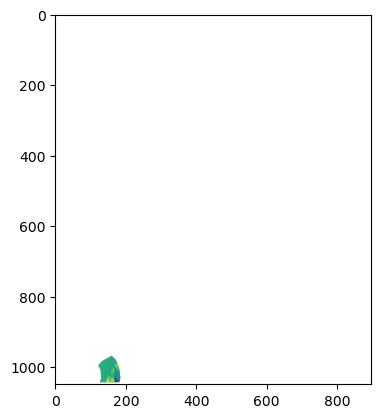

In [16]:
import urllib.request
import urllib.parse
import os.path
from osgeo import gdal
import matplotlib.pyplot as plt

gdal.UseExceptions()

# construct a vsicurl string using our headers
href = item.assets["image"].href
vsipath = f"/vsicurl?header.Authorization=Bearer%20{api_token}&url={href}"


ax = plt.gca()

ds = gdal.Open(vsipath)
band = ds.GetRasterBand(1)
data = band.ReadAsArray()
plt.imshow(data)




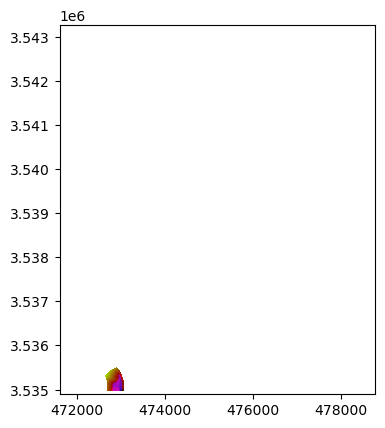

<Axes: >

In [17]:
import rasterio
import rasterio.plot


#The same can be done with rasterio
src = rasterio.open(vsipath)
xmin,ymin,xmax,ymax = item.bbox
ax = plt.gca()

rasterio.plot.show(src, cmap="terrain", transform=src.transform)

# pyplot.imshow(src.read(1), cmap='terrain')
# rasterio.plot.show(src.read(), transform=src.transform)

# rasterio.plot.show(src, cmap="terrain", ax=ax)
# plt.show()

# urlpath = urllib.parse.urlparse(href).path
# basename = os.path.basename(urlpath)
# abspath = os.path.abspath(basename)

# req = urllib.request.Request(href)
# req.add_header("Authorization", f"Bearer {api_token}")
# with urllib.request.urlopen(req) as fin:
#     data = fin.read()
#     with open(basename, 'wb') as fout:
#         fout.write(data)

# print(f"{item.id} downloaded to {abspath}")